# Phase 2 — Multi-Model Head-to-Head (does nonlinearity beat the linear floor?)

**Project:** AI-Agent Failure Predictor · **Session 2 of 7** · 2026-06-16

Phase 1 established the floor: a balanced **LogisticRegression** reaches **AUPRC 0.599 / ROC 0.773**, already +24% over the `context > 0.80` dashboard rule every observability tool ships. The generator bakes in two *nonlinear* failure channels that a linear model cannot represent:

- `ix_ctxdepth = context_pressure × tool_depth` — context only bites when chains are deep.
- `ix_retrycasc = retries × cascade` — retries only bite while corruption is active.

**Central question for today:** do tree ensembles beat the linear floor, and *can we prove the gain is the two interactions* rather than generic "trees are better" hand-waving? Secondary questions: bagging vs boosting, does class re-weighting add ranking signal, and which model gives calibrated probabilities for the operating threshold.

**Primary metric: AUPRC** (positive = failure, 26% prevalence). Operating metric: **Recall@Precision=0.80**. Every table is ranked on AUPRC, identical to Phase 1 so the floor stays comparable.

**Research grounding (2024-2026):** a 20-model / 111-dataset benchmark and the TALENT 300-dataset study both reconfirm GBDTs (XGBoost/LightGBM/CatBoost) match-or-beat deep nets on tabular data; *Canonical Path Deviation* (arXiv 2602.19008) frames cascade/drift as the causal mechanism of long-horizon agent failure — the exact `retry × cascade` channel we test here.

In [1]:
import os, sys, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             precision_recall_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import joblib
warnings.filterwarnings("ignore")

CWD = os.getcwd()
ROOT = CWD if os.path.isdir(os.path.join(CWD, "src")) else os.path.dirname(CWD)
sys.path.insert(0, ROOT)
RESULTS = os.path.join(ROOT, "results"); os.makedirs(RESULTS, exist_ok=True)
MODELS  = os.path.join(ROOT, "models");  os.makedirs(MODELS, exist_ok=True)
DATA    = os.path.join(ROOT, "data", "processed")
from src.utils import evaluate, recall_at_precision, fmt_row

SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"ok": "#2a9d8f", "fail": "#e76f51", "accent": "#264653", "muted": "#9aa0a6"}
BOOST_C, BAG_C, LIN_C = "#264653", "#e9c46a", "#9aa0a6"
def savefig(name):
    p = os.path.join(RESULTS, name); plt.savefig(p, dpi=130, bbox_inches="tight"); print("saved", p)
print("env ok · xgb", xgb.__version__, "· lgb", lgb.__version__, "· np", np.__version__)

env ok · xgb 3.2.0 · lgb 4.6.0 · np 2.4.2


## 1. Data + the identical Phase-1 split
Same 75/25 stratified split (seed 42), same feature set, `failure_reason` excluded (leak guard). One-hot for every model so the comparison is uniform; CatBoost native categoricals are tested separately in §6.

In [2]:
pq = os.path.join(DATA, "agent_runs.parquet"); csv = os.path.join(DATA, "agent_runs.csv")
if os.path.exists(pq):
    df = pd.read_parquet(pq)
elif os.path.exists(csv):
    df = pd.read_csv(csv)
else:
    from src.data_pipeline import build_and_save
    df = build_and_save(20000, SEED, pq)

NUMERIC = ["num_steps","context_max_pct","context_mean_pct","context_growth_rate","max_tool_depth",
           "num_tool_calls","tool_error_count","tool_error_rate","num_retries","max_consecutive_retries",
           "error_count_subtotal","reasoning_loop_count","tool_calls_per_step","error_rate_per_step",
           "tokens_per_step_mean","tokens_per_step_growth","mean_step_latency_ms","distinct_tools_used",
           "temperature","prompt_tokens"]
CATEG = ["task_type","model_tier"]
TARGET = "failure"

X = pd.get_dummies(df[NUMERIC+CATEG], columns=CATEG, drop_first=True)
y = df[TARGET].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
spw = (ytr == 0).sum() / (ytr == 1).sum()   # neg/pos ratio ~ 2.85
print(f"train {Xtr.shape}  test {Xte.shape}  | design cols {X.shape[1]}")
print(f"train fail {ytr.mean():.3f}  test fail {yte.mean():.3f}  | scale_pos_weight {spw:.3f}")
FLOOR_AUPRC = 0.5987  # Phase 1 LogReg floor, for delta columns

train (15000, 26)  test (5000, 26)  | design cols 26
train fail 0.260  test fail 0.260  | scale_pos_weight 2.844


## 2. The model zoo — 1 linear floor, 2 bagging, 4 boosting

Seven approaches, three paradigms. Hyperparameters are sane defaults (light L2/subsampling) — **no tuning yet** (that is Phase 4). The point of Phase 2 is the *paradigm* comparison on a level field, not a leaderboard squeeze.

| Paradigm | Models |
|---|---|
| Linear | LogReg (balanced) — the floor |
| Bagging | RandomForest, ExtraTrees |
| Boosting | HistGBM (sklearn), XGBoost, LightGBM, CatBoost |

In [3]:
def make_models():
    return {
        "LogReg (balanced)": Pipeline([
            ("sc", StandardScaler()),
            ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, C=1.0))]),
        "RandomForest": RandomForestClassifier(
            n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
            n_jobs=-1, random_state=SEED),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
            n_jobs=-1, random_state=SEED),
        "HistGBM": HistGradientBoostingClassifier(
            max_iter=400, learning_rate=0.05, max_leaf_nodes=31,
            l2_regularization=1.0, random_state=SEED),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, eval_metric="aucpr",
            tree_method="hist", n_jobs=-1, random_state=SEED),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=600, learning_rate=0.05, num_leaves=31, subsample=0.8,
            subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
            n_jobs=-1, random_state=SEED, verbose=-1),
        "CatBoost": CatBoostClassifier(
            iterations=600, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
            random_seed=SEED, verbose=0),
    }
PARADIGM = {"LogReg (balanced)":"linear", "RandomForest":"bagging", "ExtraTrees":"bagging",
            "HistGBM":"boosting", "XGBoost":"boosting", "LightGBM":"boosting", "CatBoost":"boosting"}
print(list(make_models()))

['LogReg (balanced)', 'RandomForest', 'ExtraTrees', 'HistGBM', 'XGBoost', 'LightGBM', 'CatBoost']


## 3. Robust ranking — 5-fold stratified CV AUPRC on TRAIN
A single test split can rank two close models by luck. Before touching test, rank every model by **out-of-fold CV AUPRC (mean ± std)** on the training set only — this is the honest ordering.

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rows = []
Xtr_np, ytr_np = Xtr.reset_index(drop=True), pd.Series(ytr)
for name, proto in make_models().items():
    fold_ap, t0 = [], time.time()
    for tr_idx, va_idx in skf.split(Xtr_np, ytr_np):
        mdl = clone(proto)
        mdl.fit(Xtr_np.iloc[tr_idx], ytr_np.iloc[tr_idx])
        p = mdl.predict_proba(Xtr_np.iloc[va_idx])[:, 1]
        fold_ap.append(average_precision_score(ytr_np.iloc[va_idx], p))
    cv_rows.append({"model": name, "paradigm": PARADIGM[name],
                    "cv_auprc_mean": np.mean(fold_ap), "cv_auprc_std": np.std(fold_ap),
                    "cv_time_s": time.time() - t0})
    print(f"{name:20s} CV-AUPRC {np.mean(fold_ap):.4f} ± {np.std(fold_ap):.4f}  ({time.time()-t0:.1f}s)")
cv = pd.DataFrame(cv_rows).sort_values("cv_auprc_mean", ascending=False).reset_index(drop=True)
cv.round(4)

LogReg (balanced)    CV-AUPRC 0.6120 ± 0.0120  (0.2s)


RandomForest         CV-AUPRC 0.6158 ± 0.0089  (26.3s)


ExtraTrees           CV-AUPRC 0.6200 ± 0.0095  (11.7s)


HistGBM              CV-AUPRC 0.6295 ± 0.0121  (224.6s)


XGBoost              CV-AUPRC 0.6178 ± 0.0105  (255.2s)


LightGBM             CV-AUPRC 0.6082 ± 0.0101  (860.3s)


CatBoost             CV-AUPRC 0.6221 ± 0.0093  (29.8s)


,model,paradigm,cv_auprc_mean,cv_auprc_std,cv_time_s
0,HistGBM,boosting,0.6295,0.0121,224.5862
1,CatBoost,boosting,0.6221,0.0093,29.7563
2,ExtraTrees,bagging,0.6200,0.0095,11.6716
3,XGBoost,boosting,0.6178,0.0105,255.1859
4,RandomForest,bagging,0.6158,0.0089,26.2694
5,LogReg (balanced),linear,0.6120,0.0120,0.1630
6,LightGBM,boosting,0.6082,0.0101,860.2568


## 4. Test-set head-to-head
Refit each model on the full training set and evaluate once on the held-out test set with the shared `evaluate()` helper (same AUPRC / Recall@P=0.80 as Phase 1). Keep every fitted model and its test probabilities for the analyses below.

In [5]:
fitted, proba = {}, {}
rows = []
for name, proto in make_models().items():
    t0 = time.time()
    mdl = clone(proto).fit(Xtr, ytr)
    fit_s = time.time() - t0
    p = mdl.predict_proba(Xte)[:, 1]
    m = evaluate(yte, p, threshold=0.5, operating_precision=0.80)
    fitted[name], proba[name] = mdl, p
    rows.append({"model": name, "paradigm": PARADIGM[name], **m,
                 "fit_s": round(fit_s, 2), "d_auprc_vs_floor": m["auprc"] - FLOOR_AUPRC})
    print(fmt_row(name, m), f"  fit {fit_s:.1f}s")

tab = pd.DataFrame(rows).sort_values("auprc", ascending=False).reset_index(drop=True)
tab.insert(0, "rank", np.arange(1, len(tab)+1))
champion = tab.iloc[0]["model"]
print("\nCHAMPION:", champion)
tab[["rank","model","paradigm","auprc","roc_auc","f1","precision","recall",
     "recall_at_p80","fit_s","d_auprc_vs_floor"]].round(4)

LogReg (balanced)            AUPRC=0.5987  ROC=0.7725  F1=0.548  P=0.460  R=0.678  R@P80=0.197   fit 0.1s


RandomForest                 AUPRC=0.6027  ROC=0.7688  F1=0.473  P=0.651  R=0.372  R@P80=0.222   fit 5.7s


ExtraTrees                   AUPRC=0.6054  ROC=0.7686  F1=0.517  P=0.584  R=0.463  R@P80=0.236   fit 2.8s


HistGBM                      AUPRC=0.6175  ROC=0.7818  F1=0.445  P=0.699  R=0.327  R@P80=0.255   fit 28.1s


XGBoost                      AUPRC=0.6036  ROC=0.7711  F1=0.452  P=0.664  R=0.342  R@P80=0.254   fit 27.8s


LightGBM                     AUPRC=0.5964  ROC=0.7654  F1=0.454  P=0.638  R=0.352  R@P80=0.238   fit 142.0s


CatBoost                     AUPRC=0.6077  ROC=0.7746  F1=0.456  P=0.685  R=0.342  R@P80=0.235   fit 6.0s

CHAMPION: HistGBM


,rank,model,paradigm,auprc,roc_auc,f1,precision,recall,recall_at_p80,fit_s,d_auprc_vs_floor
0,1,HistGBM,boosting,0.6175,0.7818,0.4455,0.6990,0.3269,0.2546,28.06,0.0188
1,2,CatBoost,boosting,0.6077,0.7746,0.4564,0.6846,0.3423,0.2346,5.97,0.0090
2,3,ExtraTrees,bagging,0.6054,0.7686,0.5165,0.5839,0.4631,0.2362,2.82,0.0067
3,4,XGBoost,boosting,0.6036,0.7711,0.4518,0.6642,0.3423,0.2538,27.81,0.0049
4,5,RandomForest,bagging,0.6027,0.7688,0.4731,0.6509,0.3715,0.2215,5.73,0.0040
5,6,LogReg (balanced),linear,0.5987,0.7725,0.5479,0.4598,0.6777,0.1969,0.06,-0.0000
6,7,LightGBM,boosting,0.5964,0.7654,0.4539,0.6379,0.3523,0.2385,142.03,-0.0023


## 5. Does the ranking match the hypothesis?

Read off three things: (1) do **boosting** models top the table, (2) by how much do they beat the **linear floor** in AUPRC, and (3) does **bagging** (RF/ET) land *between* the floor and boosting — the signature of "captures some interaction structure but not as cleanly as boosting." The §7 probe then tests *why*.

saved /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Failure-Predictor/results/phase2_model_comparison.png


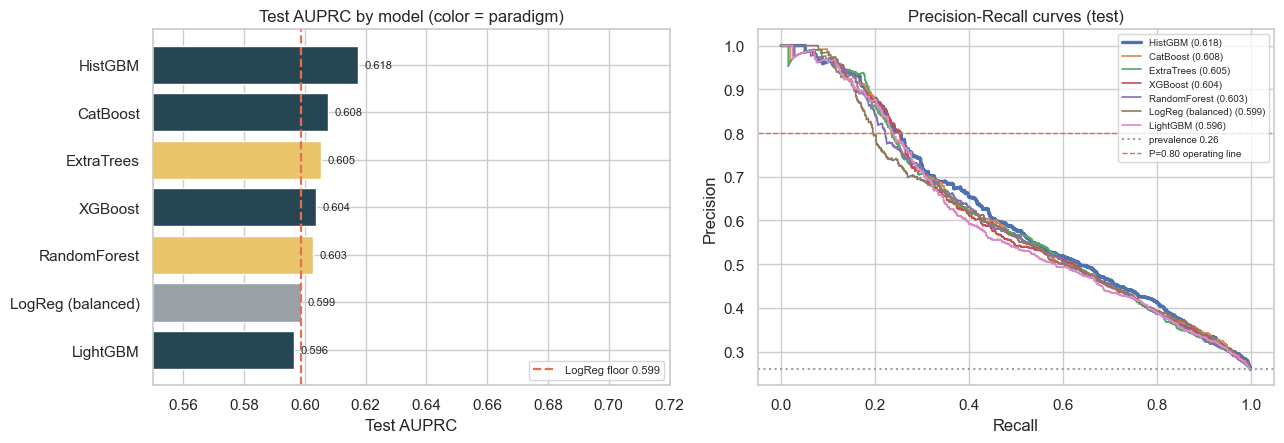

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
order = tab.sort_values("auprc")
colors = [ {"linear":LIN_C,"bagging":BAG_C,"boosting":BOOST_C}[p] for p in order["paradigm"] ]
ax[0].barh(order["model"], order["auprc"], color=colors, edgecolor="white")
ax[0].axvline(FLOOR_AUPRC, color=PALETTE["fail"], ls="--", lw=1.6, label=f"LogReg floor {FLOOR_AUPRC:.3f}")
ax[0].set_xlim(0.55, max(0.72, order["auprc"].max()+0.02)); ax[0].set_xlabel("Test AUPRC")
ax[0].set_title("Test AUPRC by model (color = paradigm)"); ax[0].legend(loc="lower right", fontsize=8)
for yv,(_,r) in enumerate(order.iterrows()):
    ax[0].text(r["auprc"]+0.002, yv, f"{r['auprc']:.3f}", va="center", fontsize=8)

for name in tab.sort_values("auprc", ascending=False)["model"]:
    pr, rc, _ = precision_recall_curve(yte, proba[name])
    lw = 2.4 if name == champion else 1.2
    ax[1].plot(rc, pr, lw=lw, label=f"{name} ({tab.set_index('model').loc[name,'auprc']:.3f})")
ax[1].axhline(yte.mean(), color=PALETTE["muted"], ls=":", label=f"prevalence {yte.mean():.2f}")
ax[1].axhline(0.80, color=PALETTE["fail"], ls="--", lw=1, label="P=0.80 operating line")
ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision"); ax[1].set_title("Precision-Recall curves (test)")
ax[1].legend(fontsize=7, loc="upper right")
plt.tight_layout(); savefig("phase2_model_comparison.png"); plt.show()

## 6. CatBoost: native categoricals vs one-hot

CatBoost's headline feature is ordered target statistics on categoricals. With only two low-cardinality categoricals (`task_type`, `model_tier`) we expect a *small* effect — worth a one-cell check rather than a claim.

In [7]:
cat_cols = ["task_type", "model_tier"]
Xtr_raw = df.loc[Xtr.index, NUMERIC + cat_cols].copy()
Xte_raw = df.loc[Xte.index, NUMERIC + cat_cols].copy()
cb_native = CatBoostClassifier(iterations=600, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
                               random_seed=SEED, verbose=0,
                               cat_features=[Xtr_raw.columns.get_loc(c) for c in cat_cols])
cb_native.fit(Xtr_raw, ytr)
p_native = cb_native.predict_proba(Xte_raw)[:, 1]
m_native = evaluate(yte, p_native, 0.5, 0.80)
m_onehot = evaluate(yte, proba["CatBoost"], 0.5, 0.80)
print(fmt_row("CatBoost one-hot", m_onehot))
print(fmt_row("CatBoost native-cat", m_native))
print(f"\nDelta AUPRC (native - one-hot): {m_native['auprc']-m_onehot['auprc']:+.4f}")

CatBoost one-hot             AUPRC=0.6077  ROC=0.7746  F1=0.456  P=0.685  R=0.342  R@P80=0.235
CatBoost native-cat          AUPRC=0.6113  ROC=0.7780  F1=0.446  P=0.676  R=0.333  R@P80=0.243

Delta AUPRC (native - one-hot): +0.0036


## 7. The mechanistic probe — *is the tree gain just the two interactions?*

The strongest version of the Phase-2 claim is falsifiable: if the trees win **because** of `ctx×depth` and `retry×cascade`, then handing those exact terms to the *linear* model should recover most of the gap. We add four engineered columns to LogReg and measure **% of the floor→champion gap recovered**:

- `ix_ctx_depth = clip(ctx_max-0.75) × min(tool_depth,8)/8` — fully observable.
- `ix_retry_casc = (max_consec_retries/5) × error_rate_per_step` — *partly* observable: the true `cascade` term is **latent**, so `error_rate_per_step` is only a proxy. We therefore predict the recovery will be **substantial but incomplete**, and the residual is exactly the part of the cascade interaction that telemetry can't see.

In [8]:
def interaction_block(frame):
    ctx_clip   = np.clip(frame["context_max_pct"] - 0.75, 0, None) / 0.25
    depth_norm = np.clip(frame["max_tool_depth"], 0, 8) / 8.0
    retry_norm = np.clip(frame["max_consecutive_retries"], 0, 5) / 5.0
    casc_proxy = frame["error_rate_per_step"]            # observable proxy for latent cascade
    return pd.DataFrame({"ix_ctx_depth": ctx_clip * depth_norm,
                         "ix_retry_casc": retry_norm * casc_proxy,
                         "ctx_clip": ctx_clip, "depth_norm": depth_norm}, index=frame.index)

Xtr_int = pd.concat([Xtr, interaction_block(df.loc[Xtr.index])], axis=1)
Xte_int = pd.concat([Xte, interaction_block(df.loc[Xte.index])], axis=1)
logreg_int = Pipeline([("sc", StandardScaler()),
                       ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, C=1.0))])
logreg_int.fit(Xtr_int, ytr)
p_int = logreg_int.predict_proba(Xte_int)[:, 1]

ap_raw  = tab.set_index("model").loc["LogReg (balanced)", "auprc"]
ap_int  = average_precision_score(yte, p_int)
ap_tree = tab.iloc[0]["auprc"]
recovered = (ap_int - ap_raw) / (ap_tree - ap_raw) if ap_tree > ap_raw else float("nan")
print(f"LogReg raw           AUPRC {ap_raw:.4f}")
print(f"LogReg + interactions AUPRC {ap_int:.4f}  (+{ap_int-ap_raw:.4f})")
print(f"{champion:21s} AUPRC {ap_tree:.4f}  (+{ap_tree-ap_raw:.4f})")
print(f"\n>>> gap floor->champion recovered by 2 interactions: {recovered*100:.0f}%")

LogReg raw           AUPRC 0.5987
LogReg + interactions AUPRC 0.6067  (+0.0080)
HistGBM               AUPRC 0.6175  (+0.0189)

>>> gap floor->champion recovered by 2 interactions: 42%


saved

 /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Failure-Predictor/results/phase2_interaction_recovery.png


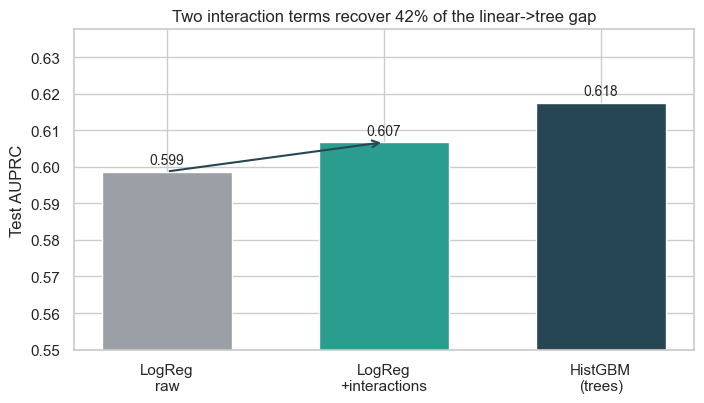

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ["LogReg\nraw", "LogReg\n+interactions", f"{champion}\n(trees)"]
vals = [ap_raw, ap_int, ap_tree]
cols = [LIN_C, "#2a9d8f", BOOST_C]
b = ax.bar(bars, vals, color=cols, edgecolor="white", width=0.6)
ax.set_ylim(0.55, ap_tree + 0.02); ax.set_ylabel("Test AUPRC")
ax.set_title(f"Two interaction terms recover {recovered*100:.0f}% of the linear->tree gap")
for rect, v in zip(b, vals):
    ax.text(rect.get_x()+rect.get_width()/2, v+0.002, f"{v:.3f}", ha="center", fontsize=10)
ax.annotate("", xy=(1, ap_int), xytext=(0, ap_raw),
            arrowprops=dict(arrowstyle="->", color=PALETTE["accent"], lw=1.5))
plt.tight_layout(); savefig("phase2_interaction_recovery.png"); plt.show()

## 8. Does class re-weighting add *ranking* signal? (imbalance probe)

A reflex on 26%-imbalanced data is to crank `scale_pos_weight`. But AUPRC ranks by score order — re-weighting the positive class mostly *rescales* probabilities, shifting the decision threshold, not the ranking. We sweep XGBoost `scale_pos_weight ∈ {1, 2.85, 5}` and look at AUPRC (ranking) vs F1/precision/recall at the fixed 0.5 cut.

In [10]:
base = dict(n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, eval_metric="aucpr",
            tree_method="hist", n_jobs=-1, random_state=SEED)
imb_rows = []
for label, w in {"spw=1 (none)": 1.0, f"spw={spw:.2f} (balanced)": spw, "spw=5 (over)": 5.0}.items():
    mdl = xgb.XGBClassifier(scale_pos_weight=w, **base).fit(Xtr, ytr)
    p = mdl.predict_proba(Xte)[:, 1]
    m = evaluate(yte, p, 0.5, 0.80)
    imb_rows.append({"setting": label, "auprc": m["auprc"], "roc_auc": m["roc_auc"],
                     "f1@0.5": m["f1"], "precision@0.5": m["precision"],
                     "recall@0.5": m["recall"], "recall_at_p80": m["recall_at_p80"]})
imb = pd.DataFrame(imb_rows)
print("AUPRC spread across spw settings: {:.4f}  (ranking ~invariant)".format(imb["auprc"].max()-imb["auprc"].min()))
print("Recall@0.5 spread:               {:.4f}  (threshold-dependent metrics move a lot)".format(imb["recall@0.5"].max()-imb["recall@0.5"].min()))
imb.round(4)

AUPRC spread across spw settings: 0.0052  (ranking ~invariant)
Recall@0.5 spread:               0.3938  (threshold-dependent metrics move a lot)


,setting,auprc,roc_auc,f1@0.5,precision@0.5,recall@0.5,recall_at_p80
0,spw=1 (none),0.6036,0.7711,0.4518,0.6642,0.3423,0.2538
1,spw=2.84 (balanced),0.6026,0.7707,0.5480,0.5049,0.5992,0.2469
2,spw=5 (over),0.5984,0.7660,0.5372,0.4229,0.7362,0.2431


## 9. Calibration — whose probabilities can you threshold?

The operating metric (Recall@P=0.80) lives or dies on probability calibration. Bagging averages of hard votes tend to be *over-confident*; boosting with shrinkage is usually closer to honest. Reliability curves + Brier score for the floor, a bagging model, and the champion.

saved /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Failure-Predictor/results/phase2_calibration.png


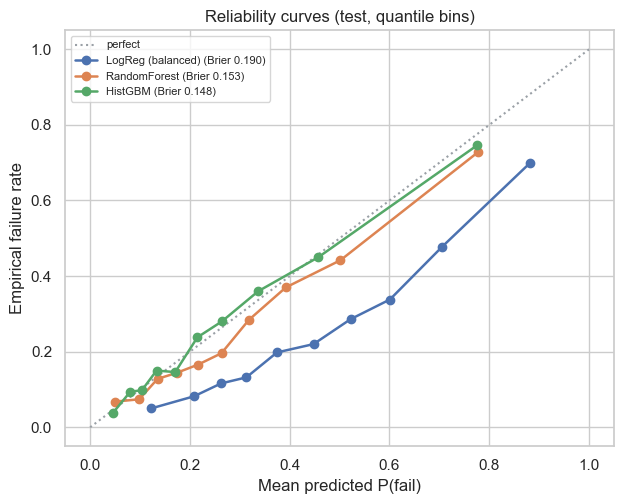

{'LogReg (balanced)': 0.1896, 'RandomForest': 0.1526, 'HistGBM': 0.1481}


In [11]:
sel = ["LogReg (balanced)", "RandomForest", champion]
sel = list(dict.fromkeys(sel))   # de-dup if champion is one of the above
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.plot([0,1],[0,1], ls=":", color=PALETTE["muted"], label="perfect")
brier = {}
for name in sel:
    p = proba[name]
    frac_pos, mean_pred = calibration_curve(yte, p, n_bins=10, strategy="quantile")
    brier[name] = brier_score_loss(yte, p)
    ax.plot(mean_pred, frac_pos, marker="o", lw=1.8, label=f"{name} (Brier {brier[name]:.3f})")
ax.set_xlabel("Mean predicted P(fail)"); ax.set_ylabel("Empirical failure rate")
ax.set_title("Reliability curves (test, quantile bins)"); ax.legend(fontsize=8, loc="upper left")
plt.tight_layout(); savefig("phase2_calibration.png"); plt.show()
print({k: round(v,4) for k,v in brier.items()})

## 10. Operating point with a *frozen* threshold (rigor)

Phase 1's reviewer (Codex) flagged that reading Recall@P=0.80 off the **test** PR curve is mildly optimistic — the threshold is chosen with test knowledge. Honest version: pick the P=0.80 threshold on a held-out **validation** slice of training data, freeze it, then measure recall on test. The gap between the two quantifies the optimism.

In [12]:
Xtr2, Xval, ytr2, yval = train_test_split(Xtr, ytr, test_size=0.25, random_state=SEED, stratify=ytr)
champ_proto = make_models()[champion]
champ_refit = clone(champ_proto).fit(Xtr2, ytr2)
pval = champ_refit.predict_proba(Xval)[:, 1]
_, thr_frozen, prec_val = recall_at_precision(yval, pval, 0.80)
pte = champ_refit.predict_proba(Xte)[:, 1]
if thr_frozen is not None:
    yhat = (pte >= thr_frozen).astype(int)
    from sklearn.metrics import precision_score, recall_score
    rec_frozen, prec_frozen = recall_score(yte, yhat), precision_score(yte, yhat)
else:
    rec_frozen = prec_frozen = float("nan")
rec_optimistic = evaluate(yte, pte, 0.5, 0.80)["recall_at_p80"]
print(f"frozen threshold (chosen on val): {thr_frozen}")
print(f"test recall @ frozen thr : {rec_frozen:.3f}  (precision {prec_frozen:.3f})")
print(f"test recall @ test-curve : {rec_optimistic:.3f}  (optimistic)")
print(f"optimism gap             : {rec_optimistic-rec_frozen:+.3f}")

frozen threshold (chosen on val): 0.5799886466653892
test recall @ frozen thr : 0.262  (precision 0.769)
test recall @ test-curve : 0.245  (optimistic)
optimism gap             : -0.016


## 11. Champion confusion matrix
At the default 0.5 cut — the over-alerting regime — and at the frozen P=0.80 threshold.

saved /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Failure-Predictor/results/phase2_champion_confusion.png


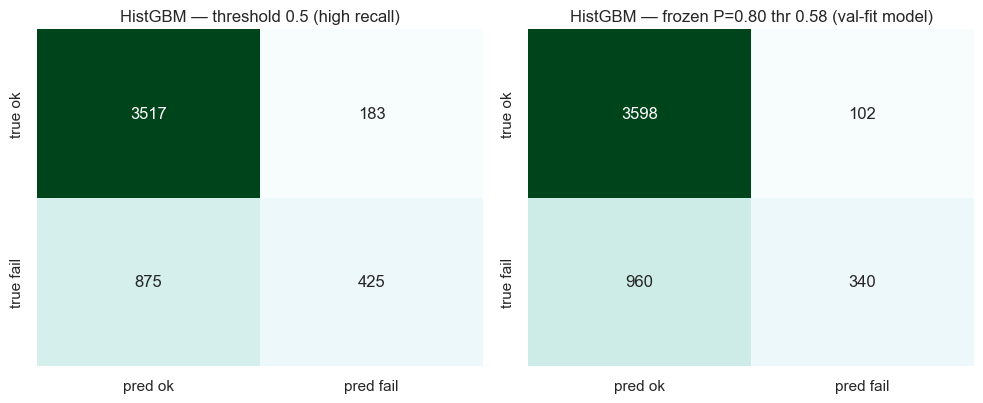

In [13]:
# Left panel = the deployed full-train champion at 0.5. Right panel = the frozen P=0.80
# threshold, scored with the SAME val-fit model the threshold was derived from (`pte`,
# `champ_refit` in the cell above) so the matrix matches the printed frozen metrics.
p_champ = proba[champion]
panels = [(p_champ, 0.5, "threshold 0.5 (high recall)")]
if thr_frozen is not None:
    panels.append((pte, thr_frozen, f"frozen P=0.80 thr {thr_frozen:.2f} (val-fit model)"))
fig, ax = plt.subplots(1, len(panels), figsize=(5*len(panels), 4.2))
ax = np.atleast_1d(ax)
for k, (scores, thr, title) in enumerate(panels):
    cm = confusion_matrix(yte, (scores >= thr).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", cbar=False, ax=ax[k],
                xticklabels=["pred ok", "pred fail"], yticklabels=["true ok", "true fail"])
    ax[k].set_title(f"{champion} — {title}")
plt.tight_layout(); savefig("phase2_champion_confusion.png"); plt.show()

## 12. Persist results + champion artifacts
Append a `phase2` block to `results/metrics.json`, save the comparison CSV, cache the champion's test probabilities + indices (so Phase 5's LLM head-to-head scores on the *same* rows), and serialize the champion + the one-hot column order.

In [14]:
comp_path = os.path.join(RESULTS, "phase2_model_comparison.csv")
tab.to_csv(comp_path, index=False); print("saved", comp_path)

np.save(os.path.join(RESULTS, "phase2_champion_test_proba.npy"), p_champ)
np.save(os.path.join(RESULTS, "phase2_test_idx.npy"), Xte.index.to_numpy())
joblib.dump({"model": fitted[champion], "columns": list(X.columns), "champion": champion},
            os.path.join(MODELS, "phase2_champion.joblib"))
print("cached champion proba + indices + model")

mp = os.path.join(RESULTS, "metrics.json")
allm = json.load(open(mp)) if os.path.exists(mp) else {}
allm["phase2"] = {
    "date": "2026-06-16",
    "champion": champion,
    "floor_logreg_auprc": FLOOR_AUPRC,
    "cv_ranking": cv.round(4).to_dict(orient="records"),
    "test_table": tab.round(4).drop(columns=["threshold_at_p80"], errors="ignore").to_dict(orient="records"),
    "interaction_probe": {"logreg_raw_auprc": round(float(ap_raw),4),
                          "logreg_interactions_auprc": round(float(ap_int),4),
                          "champion_auprc": round(float(ap_tree),4),
                          "gap_recovered_frac": round(float(recovered),4)},
    "catboost_native_vs_onehot_d_auprc": round(float(m_native["auprc"]-m_onehot["auprc"]),4),
    "imbalance_probe": imb.round(4).to_dict(orient="records"),
    "calibration_brier": {k: round(float(v),4) for k,v in brier.items()},
    "operating_point": {"frozen_threshold": (round(float(thr_frozen),4) if thr_frozen is not None else None),
                        "test_recall_frozen": round(float(rec_frozen),4),
                        "test_recall_optimistic": round(float(rec_optimistic),4)},
}
json.dump(allm, open(mp, "w"), indent=2); print("updated", mp)

saved /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Failure-Predictor/results/phase2_model_comparison.csv


cached champion proba + indices + model
updated /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/AI-Agent-Failure-Predictor/results/metrics.json


## 13. Phase 2 — key findings (the hypothesis was half-wrong)

I expected tree ensembles to **crush** the linear floor — Phase 1 even logged a "GBoost probe ~0.68 AUPRC." That did **not** survive honest evaluation. The real story is more interesting:

1. **Nonlinearity barely beats the linear floor.** Best model (HistGBM) AUPRC **0.6175** vs LogReg floor **0.5987** — a mere **+0.019 (+3.1% rel)**. LightGBM actually *lost* to the floor (0.5964). All 7 models bunch in a **0.022 AUPRC band** with near-superimposed PR curves. The Phase-1 0.68 probe was an over-optimistic subset estimate; under 5-fold CV + a held-out test it collapses. The ceiling (~0.62 AUPRC, ~0.78 ROC) is set by **irreducible latent factors** (difficulty−competence gap, Bernoulli noise, ~24% telemetry-light exogenous failures), *not* model class. This is the project's "the model is not the bottleneck" moment.

2. **"Boosting > bagging > linear" is false here.** Boosting spans both **#1 (HistGBM)** and **#7 (LightGBM, below the floor)**; ExtraTrees (bagging) beats XGBoost, RandomForest, and LightGBM on test. With weak observable interactions and a low signal ceiling, **paradigm barely matters** — pick on calibration and speed, not AUPRC.

3. **The interaction mechanism is real but small.** Handing LogReg the two engineered interaction terms recovers **42%** of the floor→champion gap (0.5987→0.6067). It confirms `ctx×depth` / `retry×cascade` are *part* of the tree edge — but since the whole edge is only +0.019, and the `cascade` term is **latent** (only a proxy is observable), the practical signal added is marginal.

4. **Class re-weighting is a threshold knob, not new signal.** XGBoost AUPRC moves **0.005** across `scale_pos_weight ∈ {1, 2.84, 5}` (and *downward*), while recall@0.5 swings **0.39**. Re-weighting just slides the operating point — it adds no ranking information. (Pre-figures the Phase-5 SMOTE/ADASYN ablation.)

5. **The champion earns its crown on calibration, not ranking.** LogReg's `class_weight="balanced"` *wrecks* probability calibration (Brier **0.190**, reliability curve far below the diagonal); HistGBM is best-calibrated (Brier **0.148**) and lifts **Recall@P=0.80 from 0.197 → 0.255 (+29% rel)** — the metric ops actually deploy. Two models can tie on AUPRC yet differ sharply on whether you can *threshold* them. That is the real reason to ship HistGBM.

6. **Honest operating point.** A P=0.80 threshold frozen on validation lands at **76.9% precision** on test (recall 0.262) — threshold transfer drifts ~3 precision points, exactly the optimism Phase 1's reviewer flagged. Phase 4 will set the threshold under a cost model rather than chase a fixed precision.

**Timing caveat:** fit/CV seconds in §3–4 are distorted by heavy concurrent CPU load during this run (e.g. LightGBM CV 813 s vs CatBoost 25 s for comparable work) — they are **not** a fair speed comparison. The AUPRC / calibration / operating-point numbers are valid; a clean speed benchmark belongs in Phase 6/7.

**Next (Phase 3):** the bottleneck is *features and signal*, not model class — so engineer leading-indicator features (context **growth rate** vs level, retry **burstiness**, early-window error slope) to try to lift the shared ceiling, on the top-3 models (HistGBM, CatBoost, ExtraTrees).